In [2]:
import xarray as xr
import numpy as np

In [3]:
from dask.diagnostics import ProgressBar

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [6]:
lowres = True

## Extract relevant CESM data

In [7]:
varnames = [
    'DIC_ALT_CO2', 'ALK_ALT_CO2', 'SiO3', 'PO4', 'TEMP', 'SALT'
]

In [8]:
if lowres:
    path = "/glade/campaign/collections/cmip/CMIP6/CESM-HR/FOSI_BGC/LR/g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.4p2z.002branch/ocn/proc/tseries/month_1/"
    prefix = "g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.4p2z.002branch.pop.h."
    suffix = ".195801-202112.nc"
    target_path = "/glade/derecho/scratch/noraloose/roms-tools-data/BGC/CESM-climatology_lowres.zarr"
    title =  "Climatology computed from the 1x1 degree CESM-MARBL simulation."
else:
    path = "/glade/campaign/collections/cmip/CMIP6/CESM-HR/FOSI_BGC/HR/g.e22.TL319_t13.G1850ECOIAF_JRA_HR.4p2z.001/ocn/proc/tseries/month_1/"
    prefix = "g.e22.TL319_t13.G1850ECOIAF_JRA_HR.4p2z.001.pop.h."
    suffix = ".*.nc"
    target_path = "/glade/derecho/scratch/noraloose/roms-tools-data/BGC/CESM-climatology_highres.zarr"
    title =  "Climatology computed from the 0.1x0.1 degree CESM-MARBL simulation."

In [9]:
def get_variable(varname):
    # get full time series of variable
    filename = f"{path}{prefix}{varname}{suffix}"
    ds_tmp = xr.open_mfdataset(filename, chunks={"z_t": 1, "z_t_150m": 1}, combine="nested", concat_dim="time", coords="minimal", compat="override")
    var = ds_tmp[varname]

    return var

In [10]:
ds = xr.Dataset()
ds.attrs["Title"] = title
ds.attrs["original_path"] = path

for varname in varnames:
    print(varname)
    var = get_variable(varname)
    ds[varname] = var

DIC_ALT_CO2
ALK_ALT_CO2
SiO3
PO4
TEMP
SALT


In [11]:
ds

<xarray.Dataset> Size: 136GB
Dimensions:      (nlat: 384, nlon: 320, time: 768, z_t: 60)
Coordinates:
    TLAT         (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG        (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT         (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULONG        (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * time         (time) object 6kB 1958-02-01 00:00:00 ... 2022-01-01 00:00:00
  * z_t          (z_t) float32 240B 500.0 1.5e+03 ... 5.125e+05 5.375e+05
Dimensions without coordinates: nlat, nlon
Data variables:
    DIC_ALT_CO2  (time, z_t, nlat, nlon) float32 23GB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    ALK_ALT_CO2  (time, z_t, nlat, nlon) float32 23GB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    SiO3         (time, z_t, nlat, nlon) float32 23GB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    PO4          (time, z_t, nlat, nlon) float32 23GB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    TEMP         (time, z_t, nlat, nlon) float32 23GB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    SALT         (time, z_t, nlat, nlon) float32 23GB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
Attributes:
    Title:          Climatology computed from the 1x1 degree CESM-MARBL simul...
    original_path:  /glade/campaign/collections/cmip/CMIP6/CESM-HR/FOSI_BGC/L...

In [12]:
ds = ds.isel(z_t=0)

In [13]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (nlat: 384, nlon: 320, time: 768)
Coordinates:
    TLAT         (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG        (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT         (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULONG        (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * time         (time) object 6kB 1958-02-01 00:00:00 ... 2022-01-01 00:00:00
    z_t          float32 4B 500.0
Dimensions without coordinates: nlat, nlon
Data variables:
    DIC_ALT_CO2  (time, nlat, nlon) float32 377MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    ALK_ALT_CO2  (time, nlat, nlon) float32 377MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    SiO3         (time, nlat, nlon) float32 377MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    PO4          (time, nlat, nlon) float32 377MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    TEMP         (time, nlat, nlon) float32 377MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    SALT         (time, nlat, nlon) float32 377MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
Attributes:
    Title:          Climatology computed from the 1x1 degree CESM-MARBL simul...
    original_path:  /glade/campaign/collections/cmip/CMIP6/CESM-HR/FOSI_BGC/L...

In [14]:
ds.to_netcdf("/glade/derecho/scratch/noraloose/Datasets/CESM/CESM-surface_lowres.nc")

## Compute carbonate sensitivity

In [1]:
import xarray as xr

In [2]:
ds = xr.open_dataset("/glade/derecho/scratch/noraloose/Datasets/CESM/CESM-surface_lowres.nc")

In [3]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (nlat: 384, nlon: 320, time: 768)
Coordinates:
    TLAT         (nlat, nlon) float64 983kB ...
    TLONG        (nlat, nlon) float64 983kB ...
    ULAT         (nlat, nlon) float64 983kB ...
    ULONG        (nlat, nlon) float64 983kB ...
  * time         (time) object 6kB 1958-02-01 00:00:00 ... 2022-01-01 00:00:00
    z_t          float32 4B ...
Dimensions without coordinates: nlat, nlon
Data variables:
    DIC_ALT_CO2  (time, nlat, nlon) float32 377MB ...
    ALK_ALT_CO2  (time, nlat, nlon) float32 377MB ...
    SiO3         (time, nlat, nlon) float32 377MB ...
    PO4          (time, nlat, nlon) float32 377MB ...
    TEMP         (time, nlat, nlon) float32 377MB ...
    SALT         (time, nlat, nlon) float32 377MB ...
Attributes:
    Title:          Climatology computed from the 1x1 degree CESM-MARBL simul...
    original_path:  /glade/campaign/collections/cmip/CMIP6/CESM-HR/FOSI_BGC/L...

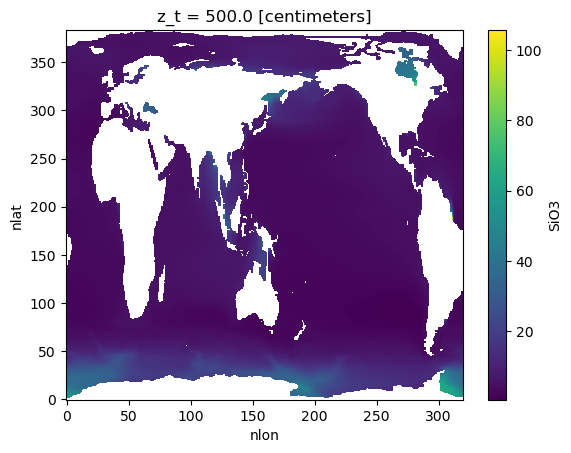

In [4]:
(ds.SiO3 * 1000 / 1025).mean(dim="time").plot()

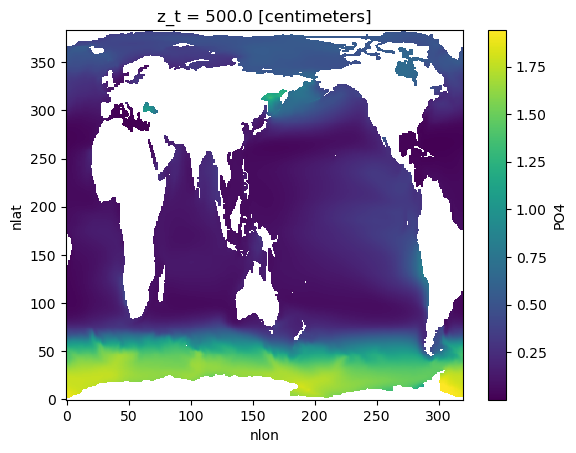

In [5]:
(ds.PO4 * 1000 / 1025).mean(dim="time").plot()

Unit conversions:

\begin{equation}
    \mu\text{mol/kg} \approx \frac{\text{mmol/m}^3 \times 1000}{\rho}
\end{equation}
​


In [6]:
import PyCO2SYS as pyco2

In [7]:
import numpy as np

In [8]:
ds["dDICdCO2"] = np.nan * xr.ones_like(ds.DIC_ALT_CO2)

In [9]:
filename = "/glade/derecho/scratch/noraloose/Datasets/CESM/CESM_carbonate_sensitivity_lowres.zarr"

In [10]:
ds.to_zarr(filename)

/glade/work/noraloose/conda-envs/deficit-tracer/lib/python3.13/site-packages/zarr/api/asynchronous.py:213: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [13]:
def compute_dDICdCO2(ds):
    csys = pyco2.sys(
        par1 = ds.ALK_ALT_CO2 * 1000 / 1025, # umol/kg
        par2 = ds.DIC_ALT_CO2 * 1000 / 1025, # umol/kg
        par1_type = 1, 
        par2_type = 2,
        salinity = ds.SALT,
        temperature = ds.TEMP,
        total_silicate = ds.PO4 * 1000 / 1025, # umol/kg
        total_phosphate = ds.SiO3 * 1000 / 1025 # umol/kg
    )
    dDICdCO2 = (
        csys["dic"] 
        - (csys["HCO3"] + 2 * csys["CO3"]) / csys["isocapnic_quotient"]
    ) / csys["CO2"]  
    
    return dDICdCO2

In [17]:
ds = ds.drop_vars(["TLAT", "TLONG", "ULAT", "ULONG", "z_t"])

In [19]:
for i in range(7):
    time_start = i * 100
    time_end = (i+1) * 100
    print(f"Compute carbonate sensitivity from t = {time_start} to t = {time_end}")
    dDICdCO2 = compute_dDICdCO2(ds.isel(time=slice(time_start, time_end)))
    dDICdCO2 = xr.DataArray(
        data=dDICdCO2, 
        coords={"time": ds.time[time_start: time_end]},
        dims=["time", "nlat", "nlon"]
    )
    ds["dDICdCO2"] = dDICdCO2
    
    ds.to_zarr(filename, region={'time': slice(time_start, time_end)})

Compute carbonate sensitivity from t = 0 to t = 100


ValueError: variable 'ALK_ALT_CO2' already exists with different dimension sizes: {'time': 100, 'nlat': 384, 'nlon': 320} != {'time': 768, 'nlat': 384, 'nlon': 320}. to_zarr() only supports changing dimension sizes when explicitly appending, but append_dim=None. If you are attempting to write to a subset of the existing store without changing dimension sizes, consider using the region argument in to_zarr().